# 图像分类2 - 使用 PyTorch 高级 API（详细注释版）

基于 torch.nn 和 torch.optim 的现代 PyTorch 写法，包含详细解释

## 0. 导入必要的库

In [18]:
import torch                          # PyTorch 核心库
import torch.nn as nn                 # 神经网络模块（Linear, ReLU, Dropout 等）
import torch.optim as optim           # 优化器（Adam, SGD 等）
import torchvision                    # 视觉相关的数据集和工具
from torch.utils.data import DataLoader  # 数据加载器，用于批处理
from torchvision import transforms   # 数据预处理和增强
import matplotlib.pyplot as plt       # 绘图库
import time                           # 用于计时

## 0.5 CUDA 加速设置（GPU 配置）

In [19]:
# ===== CUDA 加速配置 =====
print("=" * 60)
print("CUDA 加速设置")
print("=" * 60)

# 检查 CUDA 是否可用
cuda_available = torch.cuda.is_available()
print(f"\n✓ CUDA 可用: {cuda_available}")

if cuda_available:
    # 获取 GPU 信息
    gpu_count = torch.cuda.device_count()
    print(f"✓ GPU 数量: {gpu_count}")
    
    # 获取当前使用的 GPU
    current_gpu = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(current_gpu)
    print(f"✓ 当前使用的 GPU: {gpu_name}")
    
    # 获取 GPU 内存信息
    total_memory = torch.cuda.get_device_properties(current_gpu).total_memory / 1024**3  # 转换为 GB
    allocated_memory = torch.cuda.memory_allocated(current_gpu) / 1024**3
    reserved_memory = torch.cuda.memory_reserved(current_gpu) / 1024**3
    print(f"✓ GPU 显存总大小: {total_memory:.2f} GB")
    print(f"✓ 已分配显存: {allocated_memory:.2f} GB")
    print(f"✓ 保留显存: {reserved_memory:.2f} GB")
    
    # ===== CUDA 优化设置 =====
    # 1. 启用 cuDNN 的 benchmark 模式
    #    作用：自动寻找最快的卷积算法（对 CNN 加速效果显著）
    #    注意：如果输入大小变化，可能导致性能下降，因为需要重新搜索
    torch.backends.cudnn.benchmark = True
    print(f"\n✓ cuDNN benchmark 已启用（自动选择最快的算法）")
    
    # 2. 设置 cuDNN 的 deterministic 模式（可选）
    #    deterministic=True: 保证结果可重复，但可能牺牲性能
    #    deterministic=False: 运行更快，但结果可能有微小差异
    torch.backends.cudnn.deterministic = False  # 优先性能
    print(f"✓ cuDNN deterministic 已禁用（优先性能）")
    
else:
    print("\n⚠ 警告：CUDA 不可用，将使用 CPU")
    print("  如果你有 GPU，请检查：")
    print("  1. NVIDIA 驱动是否已安装")
    print("  2. CUDA Toolkit 是否已安装")
    print("  3. cuDNN 是否已安装")
    print("  4. PyTorch 是否是 GPU 版本")

print("\n" + "=" * 60)

# ===== 定义数据加载和预处理 =====
# 定义数据预处理流程
trans = transforms.Compose([
    # ToTensor(): 将图片从 PIL Image 或 numpy.ndarray 转换为张量，像素值自动归一化到 [0, 1]
    transforms.ToTensor(),
    
    # Normalize(mean, std): 标准化处理
    # 公式：x_normalized = (x - mean) / std
    # 这些是 Fashion-MNIST 数据集的统计数值
    # - mean=(0.2861,): 数据集的均值
    # - std=(0.3530,): 数据集的标准差
    # 标准化好处：加速收敛、稳定梯度、提高模型泛化能力
    transforms.Normalize(mean=(0.2861,), std=(0.3530,))
])

# 加载训练集
# - root="../data": 数据存储路径
# - train=True: 加载训练集（60000 张图片）
# - transform=trans: 应用上面定义的预处理
# - download=True: 如果本地没有数据，自动下载
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True
)

# 加载测试集
# - train=False: 加载测试集（10000 张图片）
# 测试集用于最终的模型评估，不用于训练
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True
)

print(f"\n训练集大小: {len(mnist_train)} 张图片")
print(f"测试集大小: {len(mnist_test)} 张图片")

CUDA 加速设置

✓ CUDA 可用: True
✓ GPU 数量: 1
✓ 当前使用的 GPU: NVIDIA GeForce RTX 4060 Laptop GPU
✓ GPU 显存总大小: 8.00 GB
✓ 已分配显存: 0.02 GB
✓ 保留显存: 0.03 GB

✓ cuDNN benchmark 已启用（自动选择最快的算法）
✓ cuDNN deterministic 已禁用（优先性能）


训练集大小: 60000 张图片
测试集大小: 10000 张图片


## 2. 使用 DataLoader 创建批处理加载器

In [20]:
# DataLoader 的作用：
# 1. 自动将数据分批（batch）
# 2. 自动打乱数据顺序（shuffle）
# 3. 并行加载数据（加速训练）

batch_size = 128  # 每批处理 128 张图片
                  # 更小的 batch_size：收敛更快，但梯度噪声大
                  # 更大的 batch_size：梯度更稳定，但收敛可能较慢
                  # 128 是常用的折中选择

# 训练集加载器
train_loader = DataLoader(
    mnist_train, 
    batch_size=batch_size,  # 批大小
    shuffle=True            # True: 每个 epoch 打乱数据顺序，有利于训练
)

# 测试集加载器
test_loader = DataLoader(
    mnist_test, 
    batch_size=batch_size,
    shuffle=False           # False: 测试时不需要打乱，保持顺序便于调试
)

# 计算一些统计信息
num_batches_train = len(train_loader)  # 训练集有多少个批次
num_batches_test = len(test_loader)    # 测试集有多少个批次

print(f"训练集批次数: {num_batches_train} (总样本数 ÷ batch_size = {len(mnist_train)} ÷ {batch_size})")
print(f"测试集批次数: {num_batches_test}")

训练集批次数: 469 (总样本数 ÷ batch_size = 60000 ÷ 128)
测试集批次数: 79


## 3. 定义神经网络模型

In [21]:
class FashionMNISTNet(nn.Module):
    """
    Fashion-MNIST 分类网络
    
    网络结构：
    输入 (28×28=784) → FC1(256) → ReLU → Dropout → 
    FC2(256) → ReLU → Dropout → FC3(10) → 输出概率
    """
    
    def __init__(self, input_size=784, hidden_size=256, num_classes=10):
        # input_size=784: 输入大小（28×28 的图片展平后）
        # hidden_size=256: 隐层神经元个数，更大的隐层容量更强但易过拟合
        # num_classes=10: 输出类别数（Fashion-MNIST 有 10 类）
        
        super(FashionMNISTNet, self).__init__()
        
        # 第一个全连接层（FC = Fully Connected = Dense）
        # - 输入：784 维（28×28 图片展平）
        # - 输出：256 维
        # - 参数数量：784 × 256 + 256 = 200960
        self.fc1 = nn.Linear(input_size, hidden_size)
        
        # 第二个全连接层
        # - 输入：256 维（fc1 的输出）
        # - 输出：256 维
        # - 参数数量：256 × 256 + 256 = 65792
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        
        # 第三个全连接层（输出层）
        # - 输入：256 维
        # - 输出：10 维（10 个类的得分）
        # - 参数数量：256 × 10 + 10 = 2570
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        # ReLU 激活函数
        # 作用：引入非线性，让网络能学习复杂的特征
        # 公式：ReLU(x) = max(0, x)
        # 优点：计算快、不易梯度消失
        self.relu = nn.ReLU()
        
        # Dropout 正则化
        # 作用：在训练时随机关闭部分神经元，防止过拟合
        # - p=0.2: 有 20% 的概率关闭每个神经元
        # - 在测试时自动关闭（model.eval()）
        self.dropout = nn.Dropout(p=0.2)
    
    def forward(self, x):
        """
        前向传播函数
        
        输入 x 的形状：(batch_size, 1, 28, 28)
        - batch_size: 批大小（如 128）
        - 1: 灰度图（1 个通道）
        - 28, 28: 图片大小
        """
        
        # 第一步：展平（flatten）
        # 将 (batch_size, 1, 28, 28) 变成 (batch_size, 784)
        # x.size(0) 获取 batch_size，-1 自动计算其他维度
        x = x.view(x.size(0), -1)  # 等价于 x.reshape(x.size(0), -1)
        
        # 第二步：第一个隐层
        # fc1 进行线性变换：y = x @ W + b
        # 其中 W 的形状为 (784, 256)，b 的形状为 (256,)
        x = self.fc1(x)  # 输出形状：(batch_size, 256)
        
        # 第三步：ReLU 激活
        # 对 fc1 的输出逐元素应用 ReLU
        # 作用：引入非线性，让网络能拟合非线性函数
        x = self.relu(x)  # 输出形状：(batch_size, 256)
        
        # 第四步：Dropout
        # 在训练时，随机置零 20% 的值
        # 在测试时（model.eval()），自动禁用，不置零
        x = self.dropout(x)  # 输出形状：(batch_size, 256)
        
        # 第五步：第二个隐层
        # 又一个线性变换
        x = self.fc2(x)  # 输出形状：(batch_size, 256)
        
        # 第六步：ReLU 激活
        x = self.relu(x)  # 输出形状：(batch_size, 256)
        
        # 第七步：Dropout
        x = self.dropout(x)  # 输出形状：(batch_size, 256)
        
        # 第八步：输出层
        # 线性变换到 10 维（10 个类）
        x = self.fc3(x)  # 输出形状：(batch_size, 10)
        
        # 注意：这里 NOT 应用 softmax！
        # 原因：CrossEntropyLoss 会自动对输出应用 log_softmax
        # 所以这里的输出是 logits（原始分数），不是概率
        return x

# 创建模型实例
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

model = FashionMNISTNet().to(device)  # .to(device) 将模型移到 GPU 或 CPU

# 打印模型结构
print("\n模型结构:")
print(model)

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
print(f"\n总参数数量: {total_params:,}")

使用设备: cuda

模型结构:
FashionMNISTNet(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)

总参数数量: 269,322


## 4. 定义损失函数和优化器

In [22]:
# ===== 损失函数 =====
# CrossEntropyLoss 是分类问题的标准选择
criterion = nn.CrossEntropyLoss()

# CrossEntropyLoss 的工作流程：
# 1. 对模型输出（logits）应用 softmax 转换为概率
# 2. 计算交叉熵：-Σ(y_true * log(y_pred))
# 3. 求平均（对整个 batch 的平均损失）
#
# 优点：
# - 数值稳定（避免 exp 溢出）
# - 包含 softmax，不用手写
# - 是分类问题的标准选择

print(f"损失函数: {criterion}")
print("损失函数会自动对输出应用 softmax，所以模型输出不需要 softmax")

# ===== 优化器 =====
# Adam（Adaptive Moment Estimation）
optimizer = optim.Adam(
    model.parameters(),  # 要优化的参数
    lr=0.001             # 学习率（learning rate）
                         # - 控制参数更新的步幅
                         # - 过大：收敛不稳定，易过冲
                         # - 过小：收敛太慢
                         # - 0.001 是神经网络的常用起点
)

# Adam vs SGD（随机梯度下降）：
# - SGD：简单，但学习率需要人工调整
# - Adam：自动调整学习率，通常效果更好，是现代 DL 的标准选择

print(f"\n优化器: {optimizer}")
print(f"学习率: {optimizer.param_groups[0]['lr']}")

# ===== 学习率调度器 =====
# StepLR：每隔一定 epoch 数，将学习率乘以 gamma
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,   # 每 5 个 epoch
    gamma=0.5      # 学习率乘以 0.5（即：0.001 → 0.0005 → 0.00025 ...）
)

# 学习率调度的作用：
# - 早期用较大学习率快速学习
# - 后期用较小学习率精细调整
# - 模拟退火的思想，避免在局部最优震荡

print(f"学习率调度器: {scheduler}")
print("学习率会在第 5, 10, 15, 20 个 epoch 时各降低 50%")

损失函数: CrossEntropyLoss()
损失函数会自动对输出应用 softmax，所以模型输出不需要 softmax

优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
学习率: 0.001
学习率调度器: <torch.optim.lr_scheduler.StepLR object at 0x00000225F015F810>
学习率会在第 5, 10, 15, 20 个 epoch 时各降低 50%


## 5. 定义训练和评估函数

In [23]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    训练一个 epoch
    
    参数：
    - model: 神经网络模型
    - train_loader: 训练数据加载器
    - criterion: 损失函数
    - optimizer: 优化器
    - device: 计算设备（GPU 或 CPU）
    
    返回：
    - avg_loss: 平均损失
    - accuracy: 准确率（0-1 之间）
    """
    
    # 设置模型为训练模式
    # 作用：启用 Dropout，启用 Batch Norm 的统计更新
    model.train()
    
    # 统计变量
    total_loss = 0        # 累积的损失
    correct = 0           # 正确预测的样本数
    total = 0             # 总样本数
    
    # 遍历一个 epoch 中的所有批次
    for batch_idx, (images, labels) in enumerate(train_loader):
        # images: 图片张量，形状 (batch_size, 1, 28, 28)
        # labels: 标签，形状 (batch_size,)，值为 0-9
        
        # 将数据移到指定设备（GPU 或 CPU）
        images = images.to(device)
        labels = labels.to(device)
        
        # ===== 前向传播 =====
        # 模型计算预测
        outputs = model(images)  # 形状：(batch_size, 10)
        
        # 计算损失
        loss = criterion(outputs, labels)
        
        # ===== 反向传播 =====
        # 清除之前的梯度（重要！否则梯度会累积）
        optimizer.zero_grad()
        
        # 反向传播：计算所有参数的梯度
        loss.backward()
        
        # ===== 参数更新 =====
        # 根据梯度更新参数
        # 参数 = 参数 - 学习率 * 梯度（在 Adam 中有更复杂的逻辑）
        optimizer.step()
        
        # ===== 统计 =====
        # 累积损失
        total_loss += loss.item()  # .item() 将张量转换为 Python 数字
        
        # 计算准确率
        # torch.max(outputs, 1) 返回 (最大值, 最大值的索引)
        _, predicted = torch.max(outputs.data, 1)  # predicted: (batch_size,)
        
        # 统计有多少预测正确
        total += labels.size(0)  # batch_size
        correct += (predicted == labels).sum().item()  # 正确预测数
    
    # 计算平均损失和准确率
    avg_loss = total_loss / len(train_loader)  # 对所有批次求平均
    accuracy = correct / total  # 总正确数 / 总数
    
    return avg_loss, accuracy


def evaluate(model, test_loader, criterion, device):
    """
    评估模型（在测试集或验证集上）
    
    与 train_epoch 的区别：
    - 使用 model.eval() 禁用 Dropout 和 Batch Norm
    - 使用 torch.no_grad() 禁用梯度计算（节省内存）
    - 不进行参数更新
    """
    
    # 设置模型为评估模式
    # 作用：禁用 Dropout（Dropout 只在训练时启用），
    #      禁用 Batch Norm 的统计更新（使用已有的统计值）
    model.eval()
    
    # 统计变量
    total_loss = 0
    correct = 0
    total = 0
    
    # torch.no_grad() 上下文管理器：
    # 禁用自动微分，节省内存和计算时间（评估时不需要梯度）
    with torch.no_grad():
        # 遍历所有批次
        for images, labels in test_loader:
            # 数据移到设备
            images = images.to(device)
            labels = labels.to(device)
            
            # 前向传播
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # 统计（与训练时相同）
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # 计算平均损失和准确率
    avg_loss = total_loss / len(test_loader)
    accuracy = correct / total
    
    return avg_loss, accuracy

## 6. 主训练循环

In [24]:
# 超参数
num_epochs = 20  # 训练 20 个 epoch
                 # 1 个 epoch = 遍历整个训练集一次
                 # 60000 张图片 / 128 batch_size ≈ 469 批次 per epoch

# 用于记录训练历史（用于后续可视化）
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print("=" * 80)
print("开始训练")
print("=" * 80)

# 记录总训练时间
total_start_time = time.time()

# ===== 主训练循环 =====
for epoch in range(num_epochs):
    # 记录当前 epoch 的开始时间
    epoch_start_time = time.time()
    
    # 在训练集上训练一个 epoch
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # 在测试集上评估
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    # 计算当前 epoch 的耗时
    epoch_time = time.time() - epoch_start_time
    
    # 记录历史
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # 更新学习率（根据 scheduler 的规则）
    scheduler.step()
    
    # 获取 GPU 内存使用情况（如果使用 GPU）
    if cuda_available:
        allocated_mem = torch.cuda.memory_allocated(device) / 1024**2  # 转换为 MB
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} | "
              f"Time: {epoch_time:.2f}s, GPU Memory: {allocated_mem:.0f}MB")
    else:
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} | "
              f"Time: {epoch_time:.2f}s")

# 计算总训练时间
total_time = time.time() - total_start_time

# 训练完成
print("\n" + "=" * 80)
print(f"训练完成！")
print(f"总训练时间: {total_time:.2f}s ({total_time/60:.2f} 分钟)")
print(f"平均每 epoch 时间: {total_time/num_epochs:.2f}s")
print(f"\n最终测试精度: {test_accs[-1]:.4f} ({test_accs[-1]*100:.2f}%)")
print(f"最佳测试精度: {max(test_accs):.4f} ({max(test_accs)*100:.2f}%)")
print("=" * 80)

# 清理 GPU 缓存（可选）
if cuda_available:
    torch.cuda.empty_cache()
    print("\nGPU 缓存已清理")

开始训练
Epoch [ 1/20] Train Loss: 0.5150, Train Acc: 0.8128 | Test Loss: 0.4233, Test Acc: 0.8444 | Time: 9.54s, GPU Memory: 23MB
Epoch [ 2/20] Train Loss: 0.3784, Train Acc: 0.8619 | Test Loss: 0.3693, Test Acc: 0.8665 | Time: 8.26s, GPU Memory: 23MB
Epoch [ 3/20] Train Loss: 0.3447, Train Acc: 0.8734 | Test Loss: 0.3526, Test Acc: 0.8691 | Time: 8.89s, GPU Memory: 23MB
Epoch [ 4/20] Train Loss: 0.3229, Train Acc: 0.8815 | Test Loss: 0.3585, Test Acc: 0.8666 | Time: 8.86s, GPU Memory: 23MB
Epoch [ 5/20] Train Loss: 0.3049, Train Acc: 0.8871 | Test Loss: 0.3321, Test Acc: 0.8799 | Time: 8.49s, GPU Memory: 23MB
Epoch [ 6/20] Train Loss: 0.2670, Train Acc: 0.9006 | Test Loss: 0.3209, Test Acc: 0.8832 | Time: 9.25s, GPU Memory: 23MB
Epoch [ 7/20] Train Loss: 0.2529, Train Acc: 0.9051 | Test Loss: 0.3148, Test Acc: 0.8868 | Time: 9.31s, GPU Memory: 23MB
Epoch [ 8/20] Train Loss: 0.2452, Train Acc: 0.9079 | Test Loss: 0.3165, Test Acc: 0.8877 | Time: 8.30s, GPU Memory: 23MB
Epoch [ 9/20] Train

## 7. 可视化训练过程

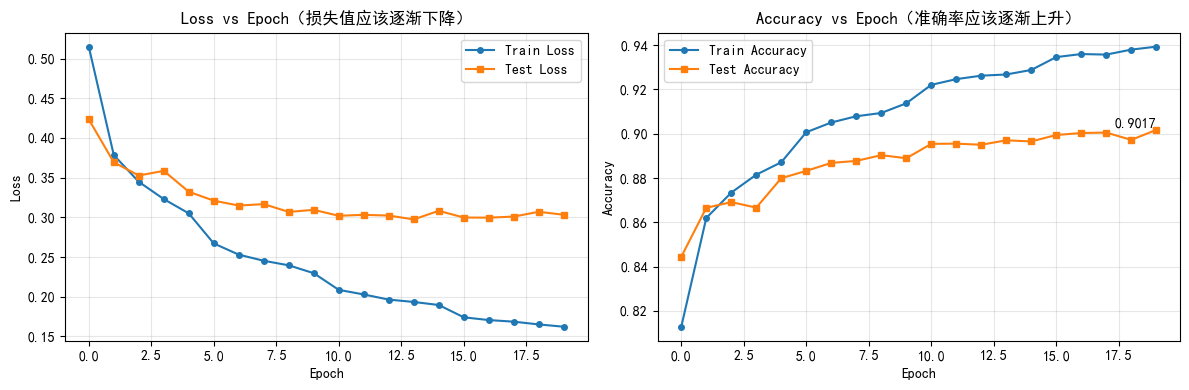


=== 训练曲线分析 ===
训练集最终损失: 0.1621
测试集最终损失: 0.3031

训练集最终准确率: 0.9393
测试集最终准确率: 0.9017

过拟合程度: 0.0376
  - 如果接近 0：模型泛化能力好
  - 如果 > 0.1：模型有轻微过拟合，可以增加 Dropout


In [25]:
# 设置 matplotlib 字体（支持中文）
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 优先使用中文字体
matplotlib.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 创建两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ===== 第一个图：损失函数曲线 =====
ax1.plot(train_losses, label='Train Loss', marker='o', markersize=4)
ax1.plot(test_losses, label='Test Loss', marker='s', markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss vs Epoch（损失值应该逐渐下降）')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 注释：如果 test_loss 开始上升，说明模型开始过拟合

# ===== 第二个图：准确率曲线 =====
ax2.plot(train_accs, label='Train Accuracy', marker='o', markersize=4)
ax2.plot(test_accs, label='Test Accuracy', marker='s', markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs Epoch（准确率应该逐渐上升）')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 注释最终精度
ax2.text(num_epochs-1, test_accs[-1], f'{test_accs[-1]:.4f}', 
         ha='right', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 分析训练曲线
print("\n=== 训练曲线分析 ===")
print(f"训练集最终损失: {train_losses[-1]:.4f}")
print(f"测试集最终损失: {test_losses[-1]:.4f}")
print(f"\n训练集最终准确率: {train_accs[-1]:.4f}")
print(f"测试集最终准确率: {test_accs[-1]:.4f}")
print(f"\n过拟合程度: {(train_accs[-1] - test_accs[-1]):.4f}")
print("  - 如果接近 0：模型泛化能力好")
print("  - 如果 > 0.1：模型有轻微过拟合，可以增加 Dropout")

## 8. 测试单个样本的预测

In [26]:
# 类别标签
def get_fashion_mnist_labels(labels):
    """将标签索引转换为文本"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

def predict_single(model, image, device):
    """
    对单个图像进行预测
    
    参数：
    - model: 模型
    - image: 单个图像张量，形状 (1, 28, 28)
    - device: 设备
    
    返回：
    - 预测的类别索引
    """
    model.eval()  # 评估模式
    with torch.no_grad():
        # unsqueeze(0)：添加 batch 维度
        # (1, 28, 28) → (1, 1, 28, 28)（batch_size=1）
        image = image.unsqueeze(0).to(device)
        output = model(image)  # (1, 10)
        _, predicted = torch.max(output, 1)  # 获取最大概率的类别
        return predicted.item()  # 返回 Python 整数

# 从测试集取一批数据
test_images, test_labels = next(iter(test_loader))

print("=== 预测样本测试 ===")
print("\n前 10 个样本的预测结果：")
print(f"{'预测':<12} | {'真实':<12} | {'结果'}")
print("-" * 35)

for i in range(min(10, len(test_images))):
    # 对每个样本进行预测
    pred = predict_single(model, test_images[i], device)
    true_label = test_labels[i].item()
    
    # 转换为标签名
    pred_name = get_fashion_mnist_labels([pred])[0]
    true_name = get_fashion_mnist_labels([true_label])[0]
    
    # 判断是否正确
    is_correct = pred == true_label
    match = "✓ 正确" if is_correct else "✗ 错误"
    
    print(f"{pred_name:<12} | {true_name:<12} | {match}")

=== 预测样本测试 ===

前 10 个样本的预测结果：
预测           | 真实           | 结果
-----------------------------------
ankle boot   | ankle boot   | ✓ 正确
pullover     | pullover     | ✓ 正确
trouser      | trouser      | ✓ 正确
trouser      | trouser      | ✓ 正确
shirt        | shirt        | ✓ 正确
trouser      | trouser      | ✓ 正确
coat         | coat         | ✓ 正确
shirt        | shirt        | ✓ 正确
sandal       | sandal       | ✓ 正确
sneaker      | sneaker      | ✓ 正确


## 9. 保存和加载模型

In [27]:
# 保存模型的两种方式：

# 方式 1：保存所有信息（推荐）
model_path = "./fashion_mnist_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),  # 模型参数
    'optimizer_state_dict': optimizer.state_dict(),  # 优化器状态
    'epoch': num_epochs,
    'test_acc': test_accs[-1],
}, model_path)
print(f"模型已保存到: {model_path}")

# 加载模型
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\n模型已加载，最终测试精度: {checkpoint['test_acc']:.4f}")

模型已保存到: ./fashion_mnist_model.pth

模型已加载，最终测试精度: 0.9017
